# 02 - Demo: fruit type and freshness

Uses the trained models in `models/` to predict the fruit and whether it is fresh or spoiled, with Grad-CAM heatmaps for the freshness decision.

The images in `demo/demo_images/` come from the test set and the file name is the true label. Other photos work too (they are cropped to a square and resized to 224 x 224). Run `scripts/train.py` and `scripts/evaluate.py` first.

In [1]:
import os, sys, glob
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
sys.path.insert(0, os.path.abspath(".."))
import numpy as np, pandas as pd, matplotlib.pyplot as plt, keras
from src.config import FRUITS, MODELS_DIR, PREDICTIONS_DIR
from src.data_pipeline import load_image
from src.evaluation.metrics import decode_outputs
from src.evaluation.gradcam import gradcam, overlay
%matplotlib inline

NAMES = {"model1_simple_cnn": "Model 1 (simple CNN)",
         "model2_multitask_cnn": "Model 2 (multi-task CNN)",
         "model3_mobilenet_v2": "Model 3 (MobileNetV2)"}
ready = [m for m in NAMES if (MODELS_DIR / f"{m}.keras").exists() and (PREDICTIONS_DIR / f"{m}_test.csv").exists()]
models = {m: keras.models.load_model(MODELS_DIR / f"{m}.keras") for m in ready}
print("Models ready:", [NAMES[m] for m in models])

def predict(paths):
    images = np.stack([load_image(p) for p in paths])
    return images, {m: decode_outputs(model.predict(images, verbose=0)) for m, model in models.items()}

def true_label(path):
    parts = os.path.basename(path)[:-4].split("_")
    return parts[-2].capitalize(), parts[-1]

Models ready: ['Model 1 (simple CNN)', 'Model 2 (multi-task CNN)', 'Model 3 (MobileNetV2)']


## 1. Predictions for the demo images

In [2]:
paths = sorted(glob.glob(os.path.join("..", "demo", "demo_images", "*.jpg")))
images, results = predict(paths)
rows = []
for i, p in enumerate(paths):
    fruit, state = true_label(p)
    row = {"image": os.path.basename(p), "true label": f"{fruit} - {state}"}
    for m, r in results.items():
        pred = f"{FRUITS[r['fruit_pred'][i]]} - {'spoiled' if r['fresh_pred'][i] else 'fresh'}"
        row[NAMES[m]] = f"{pred} (P(spoiled)={r['spoiled_prob'][i]:.2f})" + ("" if pred == f"{fruit} - {state}" else "  ✗")
    rows.append(row)
pd.set_option("display.max_colwidth", 60)
pd.DataFrame(rows)

,image,true label,Model 1 (simple CNN),Model 2 (multi-task CNN),Model 3 (MobileNetV2)
0,banana_fresh.jpg,Banana - fresh,Banana - fresh (P(spoiled)=0.00),Banana - fresh (P(spoiled)=0.00),Banana - fresh (P(spoiled)=0.00)
1,banana_spoiled.jpg,Banana - spoiled,Banana - spoiled (P(spoiled)=1.00),Banana - spoiled (P(spoiled)=1.00),Banana - spoiled (P(spoiled)=1.00)
2,hard_case_1_orange_fresh.jpg,Orange - fresh,Orange - fresh (P(spoiled)=0.00),Orange - fresh (P(spoiled)=0.00),Orange - spoiled (P(spoiled)=0.81) ✗
3,hard_case_2_tamarillo_fresh.jpg,Tamarillo - fresh,Tamarillo - fresh (P(spoiled)=0.04),Tamarillo - spoiled (P(spoiled)=0.54) ✗,Tamarillo - spoiled (P(spoiled)=0.61) ✗
4,lemon_fresh.jpg,Lemon - fresh,Lemon - fresh (P(spoiled)=0.00),Lemon - fresh (P(spoiled)=0.01),Lemon - fresh (P(spoiled)=0.00)
5,lemon_spoiled.jpg,Lemon - spoiled,Lemon - spoiled (P(spoiled)=1.00),Lemon - spoiled (P(spoiled)=0.99),Lemon - spoiled (P(spoiled)=1.00)
6,lulo_fresh.jpg,Lulo - fresh,Lulo - fresh (P(spoiled)=0.00),Lulo - fresh (P(spoiled)=0.08),Lulo - fresh (P(spoiled)=0.00)
7,lulo_spoiled.jpg,Lulo - spoiled,Lulo - spoiled (P(spoiled)=1.00),Lulo - spoiled (P(spoiled)=1.00),Lulo - spoiled (P(spoiled)=1.00)
8,mango_fresh.jpg,Mango - fresh,Mango - fresh (P(spoiled)=0.00),Mango - fresh (P(spoiled)=0.00),Mango - fresh (P(spoiled)=0.00)
9,mango_spoiled.jpg,Mango - spoiled,Strawberry - spoiled (P(spoiled)=1.00) ✗,Mango - spoiled (P(spoiled)=1.00),Mango - spoiled (P(spoiled)=1.00)


### Grad-CAM of the best model
Bright areas are the parts of the image that pushed the model towards its answer.

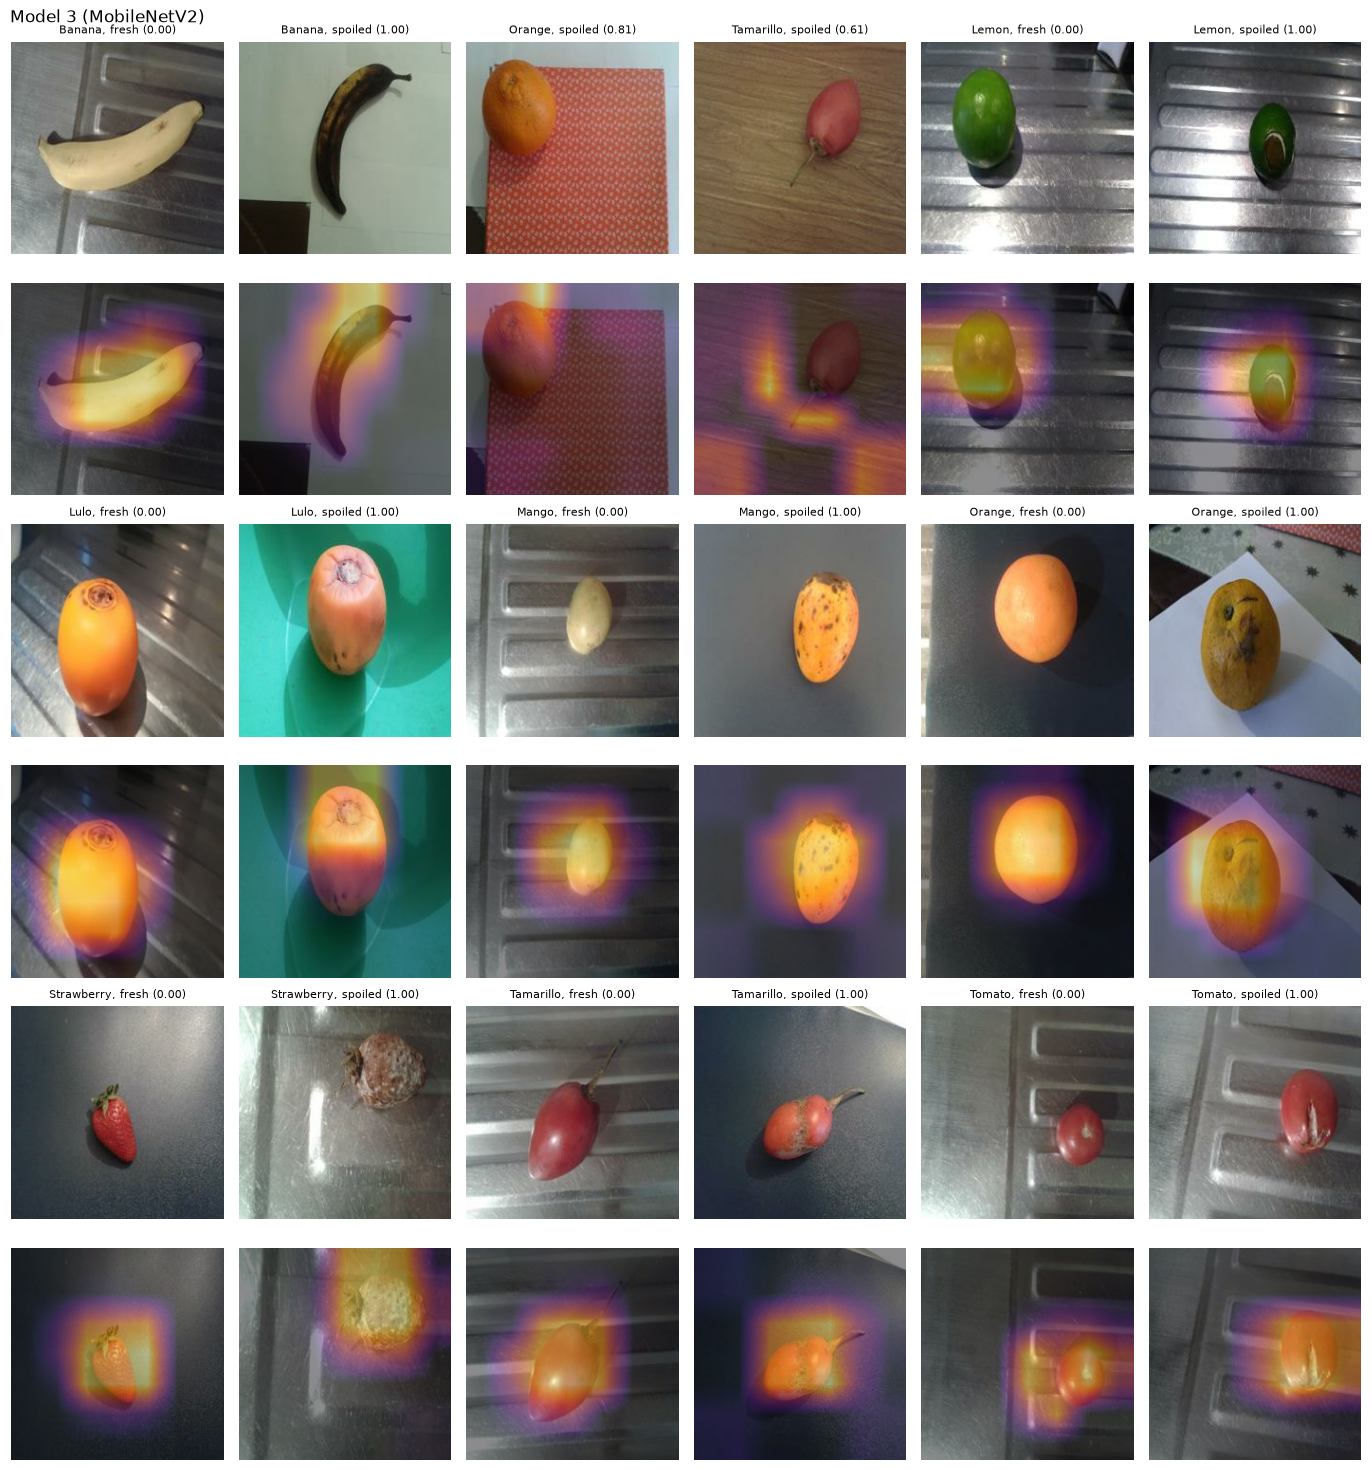

In [3]:
best = list(models)[-1]
heat = gradcam(models[best], images, "freshness")
r = results[best]
cols = 6
fig, axes = plt.subplots(int(np.ceil(len(paths) / cols)) * 2, cols, figsize=(2.3 * cols, 2.5 * 2 * np.ceil(len(paths) / cols)))
for ax in axes.ravel(): ax.axis("off")
for i, p in enumerate(paths):
    row, col = divmod(i, cols)
    axes[2 * row, col].imshow(images[i].astype("uint8"))
    axes[2 * row, col].set_title(f"{FRUITS[r['fruit_pred'][i]]}, {'spoiled' if r['fresh_pred'][i] else 'fresh'} ({r['spoiled_prob'][i]:.2f})", fontsize=8)
    axes[2 * row + 1, col].imshow(overlay(images[i], heat[i]))
plt.suptitle(NAMES[best], x=0.01, ha="left"); plt.tight_layout(); plt.show()

## 2. Your own image
Change `MY_IMAGE` to the path of a photo and run the cell again.

Model 1 (simple CNN)         -> Strawberry (p=1.00) | SPOILED (P(spoiled)=1.00)
Model 2 (multi-task CNN)     -> Strawberry (p=1.00) | SPOILED (P(spoiled)=1.00)
Model 3 (MobileNetV2)        -> Strawberry (p=1.00) | SPOILED (P(spoiled)=1.00)


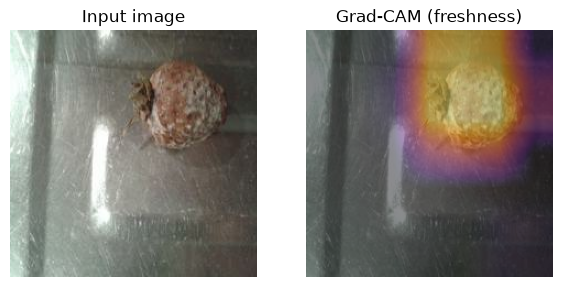

In [4]:
MY_IMAGE = os.path.join("..", "demo", "demo_images", "strawberry_spoiled.jpg")

img, res = predict([MY_IMAGE])
for m, r in res.items():
    print(f"{NAMES[m]:28s} -> {FRUITS[r['fruit_pred'][0]]:10s} (p={r['fruit_prob'][0].max():.2f}) | "
          f"{'SPOILED' if r['fresh_pred'][0] else 'fresh'} (P(spoiled)={r['spoiled_prob'][0]:.2f})")
h = gradcam(models[best], img, "freshness")
fig, ax = plt.subplots(1, 2, figsize=(7, 3.5))
ax[0].imshow(img[0].astype("uint8")); ax[0].set_title("Input image"); ax[1].imshow(overlay(img[0], h[0])); ax[1].set_title("Grad-CAM (freshness)")
for a in ax: a.axis("off")
plt.show()

## 3. Hard cases
The two `hard_case_*` images are test images where Model 3 gets the freshness wrong. The heatmaps help to see why: tiny bruises, reflections, or a label that is hard to judge.

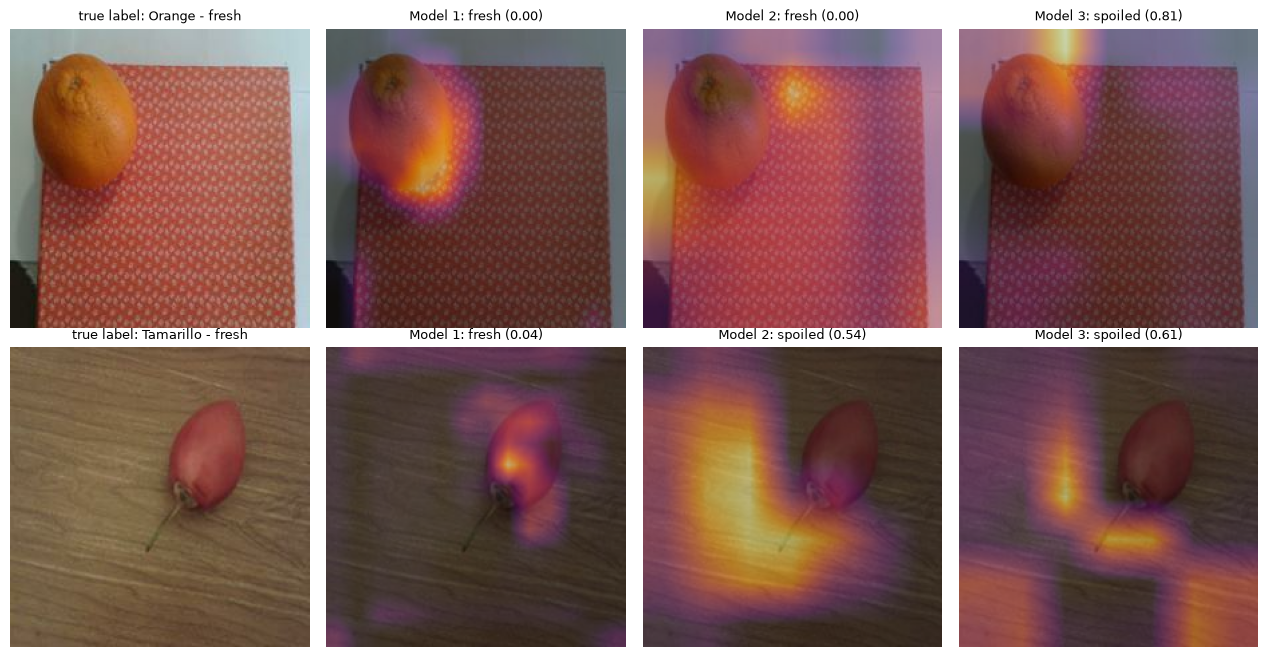

In [5]:
hard = [p for p in paths if "hard_case" in p]
img, res = predict(hard)
fig, axes = plt.subplots(len(hard), 1 + len(models), figsize=(3.2 * (1 + len(models)), 3.3 * len(hard)), squeeze=False)
for i, p in enumerate(hard):
    fruit, state = true_label(p)
    axes[i, 0].imshow(img[i].astype("uint8")); axes[i, 0].set_title(f"true label: {fruit} - {state}", fontsize=9)
    for j, (m, model) in enumerate(models.items(), start=1):
        h = gradcam(model, img[i:i + 1], "freshness")[0]
        r = res[m]
        axes[i, j].imshow(overlay(img[i], h))
        axes[i, j].set_title(f"{NAMES[m].split(' (')[0]}: {'spoiled' if r['fresh_pred'][i] else 'fresh'} ({r['spoiled_prob'][i]:.2f})", fontsize=9)
for a in axes.ravel(): a.axis("off")
plt.tight_layout(); plt.show()